# Model Comparison — Algorithms x Context Window x ABC/Category

- 3 algorithms — GCP AutoML Forecasting, BigQuery ML ARIMA_PLUS, darts N-BEATS / N-HiTS.
- Context window swept at 8, 26, 52, 104 weeks. 
- Evaluation broken out by `abc_class` and `category`.

This is the model experimentation / model selection stage. Done by comparing different forecasting approaches and different context windows rather than assuming one algorithm is automatically best.

conceptual flow:
Prepared dataset > AutoML Forecasting + ARIMA + N-BEATS / N-HiTS > Validation metrics > Model comparison > Model selection

In [1]:
!pip3 install torch --quiet
!pip install "darts[torch]>=0.41.0" statsforecast --quiet
!pip install statsforecast --quiet

In [3]:
from google.cloud import aiplatform, bigquery
import pandas as pd
import numpy as np
import itertools
import os
from datetime import datetime

# open-source comparison algorithms — same library your step-5 framework uses
from darts import TimeSeries
from darts.models import NBEATSModel, NHiTSModel

# local, free replacement for BQML's AUTO_ARIMA
# using this to save credits
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

import seaborn as sns
import matplotlib.pyplot as plt

### Project setup

In [4]:
DATANAME = "synthetic_fashion_demand"
TIMESTAMP = datetime.now().strftime("%Y%m%d%H%M%S")

project = !gcloud config get-value project
PROJECT_ID = project[0]
BUCKET = PROJECT_ID
REGION = 'us-central1'

# one GCS root for every output
GCS_DIR = f"gs://{BUCKET}/data/output"
RESULTS_PREFIX = f"gs://{BUCKET}/experiments/model_comparison/latest"

aiplatform.init(project=PROJECT_ID, location=REGION)
bq_client = bigquery.Client(project=PROJECT_ID)
print(PROJECT_ID)

fashionmvforecast


### Create gcp timeseries dataset

In [5]:
def get_or_create_timeseries_dataset(display_name: str, gcs_path: str) -> aiplatform.TimeSeriesDataset:
    existing_datasets = aiplatform.TimeSeriesDataset.list(filter=f'display_name="{display_name}"')
    if existing_datasets:
        return existing_datasets[0]
    return aiplatform.TimeSeriesDataset.create(display_name=display_name, gcs_source=[gcs_path])

gcs_path = f"gs://{BUCKET}/data/input/synthetic_fashion_demand_features.csv"
ts_dataset = get_or_create_timeseries_dataset(display_name=DATANAME, gcs_path=gcs_path)

# a plain pandas for darts and the segment evaluation
features_df = pd.read_csv(gcs_path, parse_dates=["date"])
print(f"{len(features_df):,} rows, {features_df['sku_id'].nunique():,} SKUs")

72,417 rows, 300 SKUs


### Column specs params

In [ ]:
from functions.Features_Functions import (
    TARGET_COLUMN, TIME_COLUMN, SERIES_ID_COLUMN,
    AVAILABLE_AT_FORECAST, UNAVAILABLE_AT_FORECAST,
    FORECAST_HORIZON, build_column_specs,
)

COLUMN_SPECS = build_column_specs()


### The experiment grid

In [ ]:
SEASONAL_PERIOD = 52      # weekly data, annual cycle
CONTEXT_WINDOWS = [8, 26, 52, 104]     # weeks of lookback for BQML/darts sweep
GROUP_COLS = ["category", "abc_class"]

results_log = []   # one row per (algorithm, context_window)

## Step 1: Local AutoARIMA (statsforecast), not using GCP to save costs

- Replaces BQML ARIMA_PLUS.
- Runs synchronously (it's local compute, not a remote job)

In [ ]:
RUN_LOCAL_ARIMA = True   # <- flip to False to skip re-running this and reload its last output instead

def fill_series_gaps(sku_df, sku):

    sku_df = sku_df.sort_values(TIME_COLUMN).set_index(TIME_COLUMN)
    freq = pd.infer_freq(sku_df.index)
    if freq is None:
        anchor = pd.Series(sku_df.index.day_name()).mode().iat[0][:3].upper()
        freq = f"W-{anchor}"
    full_index = pd.date_range(sku_df.index.min(), sku_df.index.max(), freq=freq)
    sku_df = sku_df.reindex(full_index)
    sku_df[TARGET_COLUMN] = sku_df[TARGET_COLUMN].fillna(0)
    sku_df[SERIES_ID_COLUMN] = sku   # restore the id for the newly-introduced gap rows
    sku_df.index.name = TIME_COLUMN
    return sku_df.reset_index()

if RUN_LOCAL_ARIMA:
    train_val_df = features_df[features_df["splits"] != "TEST"]
    filled_df = pd.concat(
        [fill_series_gaps(sku_df, sku) for sku, sku_df in train_val_df.groupby(SERIES_ID_COLUMN)],
        ignore_index=True,
    )

    sf_freq = pd.infer_freq(pd.Index(sorted(filled_df[TIME_COLUMN].unique())))

    sf_df = filled_df.rename(
        columns={SERIES_ID_COLUMN: "unique_id", TIME_COLUMN: "ds", TARGET_COLUMN: "y"}
    )[["unique_id", "ds", "y"]]

    sf = StatsForecast(models=[AutoARIMA(season_length=SEASONAL_PERIOD)], freq=sf_freq, n_jobs=-1)
    forecast_df = sf.forecast(h=FORECAST_HORIZON, df=sf_df)

    local_arima_forecast = forecast_df.rename(
        columns={"unique_id": SERIES_ID_COLUMN, "ds": TIME_COLUMN, "AutoARIMA": "predicted"}
    )

    actuals_test = (
        features_df[features_df["splits"] == "TEST"]
        [[SERIES_ID_COLUMN, TIME_COLUMN, TARGET_COLUMN]]
        .rename(columns={TARGET_COLUMN: "actual"})
    )

    local_arima_predictions_df = actuals_test.merge(
        local_arima_forecast, on=[SERIES_ID_COLUMN, TIME_COLUMN], how="inner"
    )
    local_arima_predictions_df["algorithm"] = "local_auto_arima"
    local_arima_predictions_df["context_window"] = "auto"   # no fixed knob for this one, same as BQML had

    print(f"{len(local_arima_predictions_df):,} local AutoARIMA prediction rows, non GCP")
    local_arima_predictions_df.to_csv(f"{GCS_DIR}/local_arima_predictions_df.csv", index=False)
else:
    local_arima_predictions_df = pd.read_csv(f"{GCS_DIR}/local_arima_predictions_df.csv", parse_dates=[TIME_COLUMN])
    print(f"RUN_LOCAL_ARIMA is False -- reloaded {len(local_arima_predictions_df):,} rows from a previous run")


## Step 2: Launch AutoML (non-blocking)

In [9]:
RUN_AUTOML = False   # <- flip to True once you have credits to spend again

AUTOML_CONTEXT_WINDOWS = [0, 8, 52]   # 0 = cold-start baseline, 52 = one seasonal cycle, 8 = earlier one-off

def launch_automl_experiment(context_window, budget_milli_node_hours=1000):
    job = aiplatform.AutoMLForecastingTrainingJob(
        display_name=f"{PROJECT_ID}_cw{context_window}_{TIMESTAMP}",
        optimization_objective="minimize-mae",
        column_specs=COLUMN_SPECS,
    )
    # sync=False: kicks the job off and returns immediately instead of blocking here,
    # so the next iteration of this loop can launch its job without waiting first.
    job.run(
        dataset=ts_dataset,
        target_column=TARGET_COLUMN,
        time_column=TIME_COLUMN,
        time_series_identifier_column=SERIES_ID_COLUMN,
        available_at_forecast_columns=AVAILABLE_AT_FORECAST,
        unavailable_at_forecast_columns=UNAVAILABLE_AT_FORECAST,
        forecast_horizon=FORECAST_HORIZON,
        context_window=context_window,
        data_granularity_unit="week",
        data_granularity_count=1,
        budget_milli_node_hours=budget_milli_node_hours,
        model_display_name=f"automl_cw{context_window}_{PROJECT_ID}_{TIMESTAMP}",
        predefined_split_column_name="splits",
        export_evaluated_data_items=True,   # <- writes the backtest table Step 4 reads from
        sync=False,
    )
    return job

if RUN_AUTOML:
    automl_jobs = {cw: launch_automl_experiment(cw) for cw in AUTOML_CONTEXT_WINDOWS}
    print(f"Launched {len(automl_jobs)} AutoML jobs — training on GCP")
else:
    automl_jobs = {}
    print("No job ran, if needed, set RUN_AUTOML = True")

RUN_AUTOML is False


### Reconnect to jobs (if already trained)

In [10]:
past_jobs = aiplatform.AutoMLForecastingTrainingJob.list(
    filter=f'display_name:"{PROJECT_ID}_cw"'
)
automl_jobs = {
    int(job.display_name.split("_cw")[1].split("_")[0]): job
    for job in past_jobs
    if job.display_name.split("_cw")[1].split("_")[0].isdigit()
}
print(f"Re-attached {len(automl_jobs)} AutoML jobs: {sorted(automl_jobs)}")

Re-attached 3 AutoML jobs: [0, 8, 52]


## Step 3: darts N-BEATS / N-HiTS, local model only

In [ ]:
DARTS_MODELS = {"nbeats": NBEATSModel, "nhits": NHiTSModel}

DARTS_MODEL_KWARGS = {
    "nbeats": {"num_stacks": 5, "layer_widths": 32},
    "nhits": {},   # already a lean default, left alone
}

def to_darts_series(sku_df, sku):
    filled = fill_series_gaps(sku_df, sku).set_index(TIME_COLUMN)
    freq = pd.infer_freq(filled.index)
    return TimeSeries.from_series(filled[TARGET_COLUMN], freq=freq)

def build_series_list(series_df, min_length):
    """One darts TimeSeries per SKU, dropping series too short for this context window."""
    series_list, sku_order = [], []
    for sku, sku_df in series_df.groupby(SERIES_ID_COLUMN):
        if len(sku_df) < min_length:
            continue
        ts = to_darts_series(sku_df, sku)
        if len(ts) < min_length:
            continue
        series_list.append(ts)
        sku_order.append(sku)
    return series_list, sku_order

def run_darts_experiment(model_name, input_chunk_length, series_df, n_epochs=30):
    ModelClass = DARTS_MODELS[model_name]
    min_length = 2 * input_chunk_length + 2 * FORECAST_HORIZON
    series_list, sku_order = build_series_list(series_df, min_length)
    n_total_skus = series_df[SERIES_ID_COLUMN].nunique()
    print(f"  kept {len(series_list)}/{n_total_skus} SKUs (raw length >= {min_length} weeks)")
    if not series_list:
        return pd.DataFrame(columns=[SERIES_ID_COLUMN, TIME_COLUMN, "actual", "predicted"])

    train_list = [s[:-FORECAST_HORIZON] for s in series_list]
    val_list = [s[-FORECAST_HORIZON:] for s in series_list]

    model = ModelClass(
        input_chunk_length=input_chunk_length,
        output_chunk_length=FORECAST_HORIZON,
        n_epochs=n_epochs,
        random_state=42,
        **DARTS_MODEL_KWARGS[model_name],
    )
    model.fit(train_list, dataloader_kwargs={"num_workers": min(4, os.cpu_count() or 1)})
    forecasts = model.predict(n=FORECAST_HORIZON, series=train_list)

    preds = []
    for sku, val, forecast in zip(sku_order, val_list, forecasts):
        preds.append(pd.DataFrame({
            SERIES_ID_COLUMN: sku,
            TIME_COLUMN: val.time_index,
            "actual": val.values().flatten(),
            "predicted": forecast.values().flatten(),
        }))
    return pd.concat(preds, ignore_index=True)

darts_pred_frames = []
for model_name, cw in itertools.product(DARTS_MODELS, CONTEXT_WINDOWS):
    print(f"--- darts {model_name} | context_window={cw} ---")
    preds_df = run_darts_experiment(model_name, cw, features_df)
    preds_df["algorithm"] = model_name
    preds_df["context_window"] = cw
    darts_pred_frames.append(preds_df)

darts_predictions_df = pd.concat(darts_pred_frames, ignore_index=True)
darts_predictions_df.to_csv(f"{GCS_DIR}/darts_predictions_df.csv", index=False)
print(f"Saved {len(darts_predictions_df):,} darts prediction rows to {GCS_DIR}/darts_predictions_df.csv")

### Reload data (if already trained)

In [11]:
darts_predictions_df = pd.read_csv(f"{GCS_DIR}/darts_predictions_df.csv", parse_dates=[TIME_COLUMN])
darts_predictions_df.head()

,sku_id,date,actual,predicted,algorithm,context_window
0,SKU00000,2024-11-04,35.0,26.851295,nbeats,8
1,SKU00000,2024-11-11,64.0,25.252274,nbeats,8
2,SKU00000,2024-11-18,0.0,22.500144,nbeats,8
3,SKU00000,2024-11-25,0.0,22.307933,nbeats,8
4,SKU00000,2024-12-02,8.0,23.260278,nbeats,8


## Step 4: Collect AutoML results

In [15]:
_AUTOML_COLUMNS = [SERIES_ID_COLUMN, TIME_COLUMN, "actual", "predicted", "algorithm", "context_window"]

def get_automl_backtest_predictions(job):
    evaluated_bq_table = job.evaluated_data_items_bigquery_uri
    if not evaluated_bq_table:
        raise ValueError(
            f"No evaluated-items table for {job.display_name} -- this job was trained "
            "without export_evaluated_data_items=True and can't be recovered; retrain it."
        )

    query = f"""
        SELECT {SERIES_ID_COLUMN}, {TIME_COLUMN}, {TARGET_COLUMN} AS actual,
               predicted_{TARGET_COLUMN}.value AS predicted
        FROM `{evaluated_bq_table.replace('bq://', '')}`
    """

    preds = pd.DataFrame.from_records([dict(row.items()) for row in bq_client.query(query).result()])
    preds[TIME_COLUMN] = pd.to_datetime(preds[TIME_COLUMN]).dt.tz_localize(None)
    return preds

if automl_jobs:
    automl_pred_frames = []
    for cw, job in automl_jobs.items():
        job.wait()   # no-op / instant if the job already finished training
        model = job.get_model()

        for evaluation in model.list_model_evaluations():
            metrics = evaluation.to_dict().get("metrics", {})
            results_log.append({
                "algorithm": "automl", "context_window": cw,
                "model_resource_name": model.resource_name,
                "rmse": metrics.get("rootMeanSquaredError"),
                "mae": metrics.get("meanAbsoluteError"),
                "mape": metrics.get("meanAbsolutePercentageError"),
            })

        preds = get_automl_backtest_predictions(job)
        preds["algorithm"] = "automl"
        preds["context_window"] = cw
        automl_pred_frames.append(preds)

    automl_predictions_df = pd.concat(automl_pred_frames, ignore_index=True) if automl_pred_frames else pd.DataFrame(columns=_AUTOML_COLUMNS)
    print(f"{len(automl_predictions_df):,} AutoML prediction rows")
    automl_predictions_df.to_csv(f"{GCS_DIR}/automl_predictions_df.csv", index=False)
else:
    automl_predictions_df = pd.DataFrame(columns=_AUTOML_COLUMNS)
    print("automl_jobs is empty -- nothing launched or reconnected, 0 AutoML rows.")

AutoMLForecastingTrainingJob run completed. Resource name: projects/456832640267/locations/us-central1/trainingPipelines/1717453251533602816
Model available at projects/456832640267/locations/us-central1/models/3682898309875236864
AutoMLForecastingTrainingJob run completed. Resource name: projects/456832640267/locations/us-central1/trainingPipelines/5527498536289042432
Model available at projects/456832640267/locations/us-central1/models/7317303209163227136
AutoMLForecastingTrainingJob run completed. Resource name: projects/456832640267/locations/us-central1/trainingPipelines/8409802297806159872
Model available at projects/456832640267/locations/us-central1/models/2705617190735839232
32,400 AutoML prediction rows


## Evaluating at the ABC and category levels

In [16]:
def wape(actual, predicted):
    actual, predicted = np.asarray(actual, dtype=float), np.asarray(predicted, dtype=float)
    denom = np.abs(actual).sum()
    return np.abs(actual - predicted).sum() / denom if denom else np.nan

def evaluate_by_segment(predictions_df, meta_df, group_cols=GROUP_COLS):
    meta = meta_df[[SERIES_ID_COLUMN] + group_cols].drop_duplicates(subset=SERIES_ID_COLUMN)
    df = predictions_df.merge(meta, on=SERIES_ID_COLUMN, how="left")

    def _summary(g):
        return pd.Series({"wape": wape(g["actual"], g["predicted"]), "n_skus": g[SERIES_ID_COLUMN].nunique()})

    overall = df.groupby(["algorithm", "context_window"]).apply(_summary).reset_index()
    by_category = df.groupby(["algorithm", "context_window", "category"]).apply(_summary).reset_index()
    by_abc = df.groupby(["algorithm", "context_window", "abc_class"]).apply(_summary).reset_index()
    return overall.sort_values("wape"), by_category.sort_values("wape"), by_abc.sort_values("wape")

combined_predictions_df = pd.concat(
    [automl_predictions_df, local_arima_predictions_df, darts_predictions_df],
    ignore_index=True,
)

overall, by_category, by_abc = evaluate_by_segment(combined_predictions_df, features_df)

print("Overall leaderboard (lower WAPE = better):")
display(overall)
print("\nBy category:")
display(by_category)
print("\nBy ABC class:")
display(by_abc)

Overall leaderboard (lower WAPE = better):


,algorithm,context_window,wape,n_skus
1,automl,8,0.281416,300.0
2,automl,52,0.312435,300.0
0,automl,0,0.357978,300.0
10,nhits,52,0.377740,278.0
6,nbeats,52,0.400921,278.0
4,nbeats,8,0.405870,300.0
11,nhits,104,0.409160,256.0
8,nhits,8,0.410423,300.0
7,nbeats,104,0.412987,256.0
9,nhits,26,0.428558,297.0



By category:


,algorithm,context_window,category,wape,n_skus
8,automl,8,Dresses,0.241919,62.0
9,automl,8,Footwear,0.265670,63.0
15,automl,52,Footwear,0.266729,63.0
11,automl,8,Tops,0.268493,49.0
6,automl,8,Accessories,0.286865,35.0
...,...,...,...,...,...
50,nhits,8,Dresses,0.626567,62.0
23,local_auto_arima,auto,Tops,0.676340,49.0
56,nhits,26,Dresses,0.778854,61.0
32,nbeats,26,Dresses,0.855354,61.0



By ABC class:


,algorithm,context_window,abc_class,wape,n_skus
3,automl,8,1.0,0.262877,158.0
0,automl,0,1.0,0.291171,158.0
6,automl,52,1.0,0.295444,158.0
4,automl,8,2.0,0.316280,72.0
5,automl,8,3.0,0.322855,70.0
8,automl,52,3.0,0.339970,70.0
7,automl,52,2.0,0.355834,72.0
1,automl,0,2.0,0.360972,72.0
30,nhits,52,1.0,0.362611,158.0
12,nbeats,8,1.0,0.383682,158.0


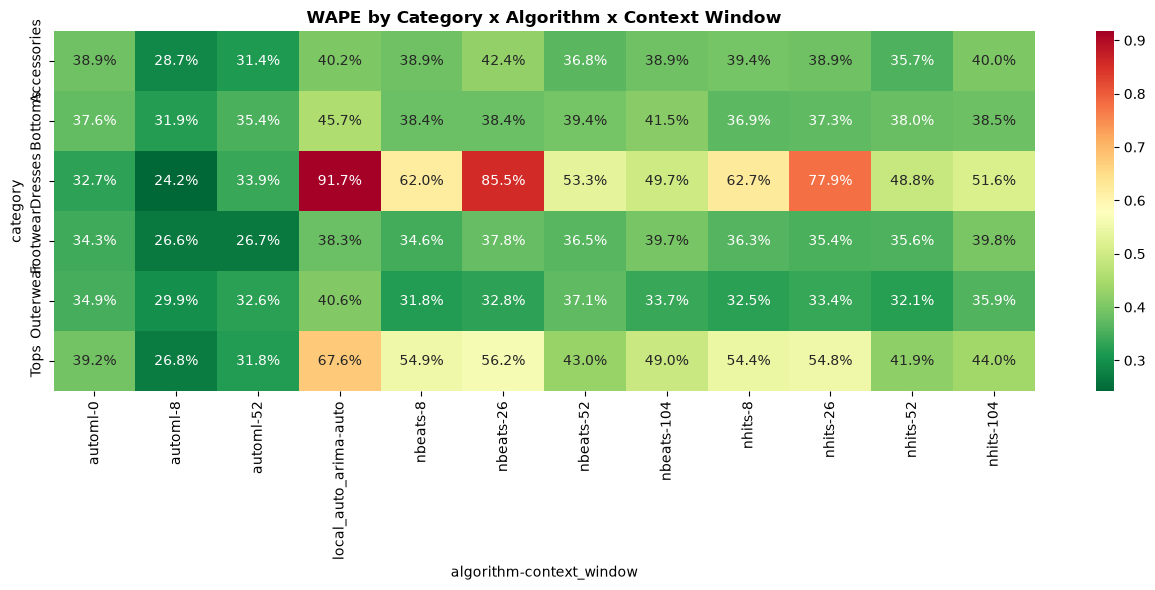

In [17]:
pivot = by_category.pivot_table(index="category", columns=["algorithm", "context_window"], values="wape")

plt.figure(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn_r")
plt.title("WAPE by Category x Algorithm x Context Window", fontweight="bold")
plt.tight_layout()
plt.show()

## Reading the results

- **ABC class** — A-class SKUs (highest-value/volume) usually have
  the most stable history and are the easiest to get right; if WAPE is
  still bad there, that's the priority to fix before anything else.
  C-class SKUs are often low-volume/intermittent.
- **Category** — a category-level gap that shows up consistently across
  algorithms (e.g. every model struggles on Dresses) points at a
  feature or data problem, not a model problem. 
- **Context window** — watch for the point where a larger window stops
  improving WAPE. That's your evidence for what context_window/
  input_chunk_length to actually use going forward, instead of an
  undocumented 0 or a library default

## 5.1: Hand off to experiment tracking

Storing values for Experiment_Tracking to pick up

In [18]:
pd.DataFrame(results_log).to_csv(f"{RESULTS_PREFIX}/results_log.csv", index=False)
overall.to_csv(f"{RESULTS_PREFIX}/overall.csv", index=False)
by_category.to_csv(f"{RESULTS_PREFIX}/by_category.csv", index=False)
by_abc.to_csv(f"{RESULTS_PREFIX}/by_abc.csv", index=False)

print(f"Wrote results to {RESULTS_PREFIX}/ — pick up from here in 5b_Experiment_Tracking.ipynb")

Wrote results to gs://fashionmvforecast/experiments/model_comparison/latest/ — pick up from here in 5b_Experiment_Tracking.ipynb
